# Load Experiment Data from JSONL

This notebook loads experiment data from the sweep results JSONL file and prepares it for analysis.

## 1. Import Libraries

In [1]:
import json
import pandas as pd
from pathlib import Path

## 2. Define the JSONL File Path

In [2]:
# Define the path to the JSONL file
file_path = Path("results/experiments/54823c03daf86add/sweep.jsonl")

# Verify that the file exists
if file_path.exists():
    print(f"✓ File found: {file_path.absolute()}")
    print(f"  File size: {file_path.stat().st_size} bytes")
else:
    print(f"✗ File not found: {file_path.absolute()}")
    raise FileNotFoundError(f"The file {file_path} does not exist.")

✓ File found: /export/ssule25/hyperparameters-bilevel-optimization/results/experiments/54823c03daf86add/sweep.jsonl
  File size: 104983678 bytes


## 3. Load JSONL Records

In [3]:
# Read the JSONL file line by line and parse each JSON object
records = []

with open(file_path, 'r') as f:
    for line_num, line in enumerate(f, 1):
        try:
            record = json.loads(line)
            records.append(record)
        except json.JSONDecodeError as e:
            print(f"Warning: Failed to parse line {line_num}: {e}")

print(f"✓ Loaded {len(records)} records from the JSONL file")

✓ Loaded 96000 records from the JSONL file


## 4. Convert Loaded Data to a DataFrame

In [4]:
# Create a pandas DataFrame from the loaded records
df = pd.DataFrame(records)

print(f"✓ Created DataFrame with shape: {df.shape}")
print(f"  Rows: {df.shape[0]}, Columns: {df.shape[1]}")

✓ Created DataFrame with shape: (96000, 35)
  Rows: 96000, Columns: 35


## 5. Inspect and Validate the Data

In [5]:
# Display the first few rows
print("First few rows of the data:")
print(df.head())

print("\n" + "="*80 + "\n")

# Display the schema (column names and types)
print("DataFrame Schema:")
print(df.dtypes)

print("\n" + "="*80 + "\n")

# Display summary statistics
print("Data Summary:")
print(df.info())

print("\n" + "="*80 + "\n")

# Display any missing values
print("Missing Values:")
print(df.isnull().sum())

First few rows of the data:
   best_solution_V  best_solution_c0_hat  best_solution_c1_hat  \
0         0.060460              0.445766              0.443854   
1         0.091450              0.448025              0.446182   
2         0.043397              0.446230              0.444306   
3         0.079928              0.455404              0.453526   
4         0.062178              0.455872              0.454070   

   best_solution_error  best_solution_forward_error  best_solution_iter  \
0             0.176143                     0.012232                 0.0   
1             0.176140                     0.007982                 0.0   
2             0.176130                     0.010430                 0.0   
3             0.176142                     0.008091                 0.0   
4             0.176180                     0.007754                 0.0   

   best_solution_lambda0_hat  best_solution_lambda1_hat  best_solution_mu  \
0                   0.004456                   

# Sort and visualize

In [6]:
df.columns
df = df[df['status'] != 'failed']

In [7]:
df.columns

Index(['best_solution_V', 'best_solution_c0_hat', 'best_solution_c1_hat',
       'best_solution_error', 'best_solution_forward_error',
       'best_solution_iter', 'best_solution_lambda0_hat',
       'best_solution_lambda1_hat', 'best_solution_mu', 'c0_true', 'c1_true',
       'experiment_id', 'final_V', 'final_c0_hat', 'final_c1_hat',
       'final_forward_error', 'final_iter', 'final_lambda0_hat',
       'final_lambda1_hat', 'final_mu', 'final_solution_error', 'job_index',
       'lambda0_true', 'lambda1_true', 'method', 'n_outer_iterations',
       'noise_type', 'realization', 'runtime_seconds', 'seed', 'status',
       'task_index', 'error_message', 'error_type', 'traceback'],
      dtype='str')

In [ ]:
# Quantity to plot. Change this to 'lambda0' or 'lambda1' to plot MSE for those estimates instead.
plot_key = 'lambda0'
colormap_name = 'plasma'

metric_labels = {
    'c1': 'MSE of c1 estimate',
    'lambda0': 'MSE of lambda0 estimate',
    'lambda1': 'MSE of lambda1 estimate',
    'mu': 'Mean of mu estimate'
}

metric_label = metric_labels[plot_key]

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401; registers the 3D projection


def squared_error(pred, true):
    return (pred - true) ** 2

def rmse(pred, true):
    return np.sqrt(np.mean((pred - true) ** 2))
def rmse_std(pred, true):
    return np.std(pred - true)
def rel_rmse(pred, true):
    errors_vec = 1 - (pred / true)
    return np.sqrt(np.mean(errors_vec ** 2))
def rel_rmse_std(pred, true):
    errors_vec = 1 - (pred / true)
    return np.std(errors_vec)

def metric_values(subset, key, error_fn):
    if key == 'c1':
        return error_fn(subset['final_c1_hat'], subset['c1_true'])
    if key == 'lambda0':
        return error_fn(subset['final_lambda0_hat'], subset['lambda0_true'])
    if key == 'lambda1':
        return error_fn(subset['final_lambda1_hat'], subset['lambda1_true'])
    if key == 'mu': 
        return np.mean(subset['final_mu'])
    raise ValueError(f"Unknown plot_key: {key}")

In [ ]:
def build_mean_and_std_tables(combo_df, key, error_fn):
    lambda0_values = sorted(combo_df['lambda0_true'].dropna().unique())
    lambda1_values = sorted(combo_df['lambda1_true'].dropna().unique())

    mean_table = np.full((len(lambda0_values), len(lambda1_values)), np.nan)
    std_table = np.full_like(mean_table, np.nan, dtype=float)

    if not lambda0_values or not lambda1_values:
        return lambda0_values, lambda1_values, mean_table, std_table

    summary_df = combo_df.copy()
    summary_df['_plot_value'] = metric_values(summary_df, key, error_fn)
    summary = summary_df.groupby(['lambda0_true', 'lambda1_true'])['_plot_value'].agg(['mean', 'std'])

    for i, lambda0 in enumerate(lambda0_values):
        for j, lambda1 in enumerate(lambda1_values):
            if (lambda0, lambda1) in summary.index:
                mean_table[i, j] = summary.loc[(lambda0, lambda1), 'mean']
                std_table[i, j] = summary.loc[(lambda0, lambda1), 'std']

    return lambda0_values, lambda1_values, mean_table, std_table

In [24]:
def plot_3d_histogram_with_error_bars(
    mean_table,
    std_table,
    lambda0_values,
    lambda1_values,
    noise_type,
    c1_true,
    method,
    label,
    set_z_lims=True,
    save_path=None
):
    lambda0_grid, lambda1_grid = np.meshgrid(lambda0_values, lambda1_values, indexing='ij')

    dx = np.min(np.diff(lambda0_values)) * 0.8 if len(lambda0_values) > 1 else 0.1
    dy = np.min(np.diff(lambda1_values)) * 0.8 if len(lambda1_values) > 1 else 0.1

    x_center = lambda0_grid.ravel()
    y_center = lambda1_grid.ravel()
    x = x_center - dx / 2
    y = y_center - dy / 2
    z = np.zeros_like(x, dtype=float)
    dz = mean_table.ravel()
    zerr = np.nan_to_num(std_table.ravel(), nan=0.0)

    finite_mask = np.isfinite(dz)
    if not finite_mask.any():
        print(f"Skipping noise_type={noise_type}, c1_true={c1_true}, method={method}: no finite values")
        return

    z_axis_limit = 0.05 * (c1_true ** 2)
    colormap = plt.get_cmap(colormap_name)
    if set_z_lims:
        norm = Normalize(vmin=0.0, vmax=z_axis_limit, clip=True)
    else:
        norm = Normalize(vmin=0.0, vmax=1.0, clip=True)
    colors = colormap(norm(dz[finite_mask]))

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.bar3d(
        x[finite_mask],
        y[finite_mask],
        z[finite_mask],
        dx,
        dy,
        dz[finite_mask],
        color=colors,
        edgecolor='black',
        linewidth=0.3,
        alpha=0.4,
        shade=True,
    )
    ax.errorbar(
        x_center[finite_mask],
        y_center[finite_mask],
        dz[finite_mask],
        zerr=zerr[finite_mask],
        fmt='none',
        ecolor='black',
        elinewidth=0.5,
        capsize=3,
    )

    mappable = cm.ScalarMappable(norm=norm, cmap=colormap)
    mappable.set_array(dz[finite_mask])
    colorbar = fig.colorbar(mappable, ax=ax, shrink=0.65, pad=0.1, label=label)
    colorbar.solids.set_alpha(0.65)
    colorbar.outline.set_alpha(0.4)

    ax.set_xlabel('lambda0_true')
    ax.set_ylabel('lambda1_true')
    ax.set_zlabel(label)
    ax.grid(False)
    ax.set_title(f'{label}\nnoise_type={noise_type}, c1_true={c1_true:g}, method={method}')
    ax.view_init(elev=25, azim=-135)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    # plt.show()
    plt.close(fig)

In [25]:
plot_combinations = list(
    df[['noise_type', 'c1_true', 'method']]
    .drop_duplicates()
    .sort_values(['noise_type', 'c1_true', 'method'])
    .itertuples(index=False, name=None)
)

print(f"Found {len(plot_combinations)} noise_type/c1_true/method combinations to plot.")

Found 24 noise_type/c1_true/method combinations to plot.


In [ ]:
from tqdm import tqdm
import os 
for noise_type, current_c1_true, method in tqdm(plot_combinations, desc='plot combinations'):
    combo_df = df[
        (df['noise_type'] == noise_type)
        & np.isclose(df['c1_true'], current_c1_true, atol=1e-9)
        & (df['method'] == method)
    ]

    if combo_df.empty:
        continue

    lambda0_values, lambda1_values, mean_table, std_table = build_mean_and_std_tables(combo_df, plot_key, rel_rmse)
    save_path = f'{os.getcwd()}/plots/3d_histogram_{noise_type}_{current_c1_true:.4f}_{method}.png'
    plot_3d_histogram_with_error_bars(
        mean_table=mean_table,
        std_table=std_table,
        lambda0_values=lambda0_values,
        lambda1_values=lambda1_values,
        noise_type=noise_type,
        c1_true=current_c1_true,
        method=method,
        label=metric_label,
        set_z_lims=True,
        save_path=save_path
    )

plot combinations: 100%|██████████| 24/24 [00:23<00:00,  1.00it/s]


In [ ]:
# All 3D histogram plots are generated by the loop above.

In [134]:
# sort by c1_true 
import matplotlib.pyplot as plt
import numpy as np

c1_true = 0.1
# plot the 2d errors averaged over noise and multistart 
n_lambda1 = df.param1_true.unique().shape[0]
n_lambda2 = df.param2_true.unique().shape[0]
results = {'c1': {'rmse': np.zeros((n_lambda1, n_lambda2)),\
     'std': np.zeros((n_lambda1, n_lambda2))}, \
     'param1': {'rmse': np.zeros((n_lambda1, n_lambda2)),\
     'std': np.zeros((n_lambda1, n_lambda2))}, \
      'param2': {'rmse': np.zeros((n_lambda1, n_lambda2)),\
     'std': np.zeros((n_lambda1, n_lambda2))}, \
     'overall': {'rmse': np.zeros((n_lambda1, n_lambda2)), \
     'std': np.zeros((n_lambda1, n_lambda2))}}  

In [135]:
if len(df.use_inverses.unique()) > 0:
    if df.use_inverses.unique()[0]:
        param1_true, param2_true = 'T21_true', 'T22_true'
        param1_hat, param2_hat = 'T21_hat', 'T22_hat'
    else:
        param1_true, param2_true = 'lambda1_true', 'lambda2_true'
        param1_hat, param2_hat = 'lambda1_hat', 'lambda2_hat'
else:
    print(f"Mixed use_inverses values found. Cannot determine param1 and param2.")

In [136]:
for i in range(n_lambda1):
    for j in range(i, n_lambda2):
        param1_true_values = df[param1_true].unique()[i]
        param2_true_values = df[param2_true].unique()[j]
        df_subset = df[(np.isclose(df.c1_true, c1_true, atol=1e-9))\
             & (np.isclose(df[param1_true], param1_true_values, atol=1e-9)) \
             & (np.isclose(df[param2_true], param2_true_values, atol=1e-9))]
        # plot the 2d errors averaged over noise and multistart 
        results['c1']['rmse'][i, j] = rel_rmse(df_subset.c1_hat, df_subset.c1_true)
        results['c1']['std'][i, j] = rel_rmse_std(df_subset.c1_hat, df_subset.c1_true)  
        results['param1']['rmse'][i, j] = rel_rmse(df_subset[param1_hat], df_subset[param1_true])
        results['param1']['std'][i, j] = rel_rmse_std(df_subset[param1_hat], df_subset[param1_true])
        results['param2']['rmse'][i, j] = rel_rmse(df_subset[param2_hat], df_subset[param2_true])
        results['param2']['std'][i, j] = rel_rmse_std(df_subset[param2_hat], df_subset[param2_true])
        results['overall']['rmse'][i, j] = np.sqrt(rel_rmse(df_subset.c1_hat, df_subset.c1_true)**2 + \
            rel_rmse(df_subset[param1_hat], df_subset[param1_true])**2 + \
            rel_rmse(df_subset[param2_hat], df_subset[param2_true])**2)
        results['overall']['std'][i, j] = np.sqrt(results['c1']['std'][i, j]**2 + \
            results['param1']['std'][i, j]**2 + \
            results['param2']['std'][i, j]**2)

In [137]:
results['param2']['rmse']

array([[1.78887553, 1.10482522, 1.61546257, 1.73041568, 0.77344099,
        1.21300584, 0.97903405, 0.86448907, 0.79043672, 0.61832355,
        0.48008031, 0.42148561, 0.35892341, 0.30922502, 0.27546451,
        0.25942951, 0.21874767, 0.2379598 , 0.19652025, 0.2861073 ],
       [0.        , 2.21505693, 1.40183508, 1.60731346, 1.33638599,
        0.92394616, 0.9132552 , 0.85725328, 0.68188494, 0.53720722,
        0.50131445, 0.40085112, 0.35489964, 0.31807833, 0.24850142,
        0.18297203, 0.22203181, 0.23960935, 0.20040049, 0.16589908],
       [0.        , 0.        , 1.6611228 , 1.57834865, 0.61864836,
        1.04170204, 0.89305762, 0.59080778, 0.524724  , 0.49149465,
        0.49913406, 0.41259976, 0.36366395, 0.34223842, 0.31507367,
        0.17761262, 0.18410512, 0.13548481, 0.16868928, 0.11535331],
       [0.        , 0.        , 0.        , 1.26642039, 1.3596496 ,
        0.78182048, 0.7915537 , 0.61758048, 0.6598968 , 0.44120459,
        0.47677807, 0.38177077, 0.34125205, 0

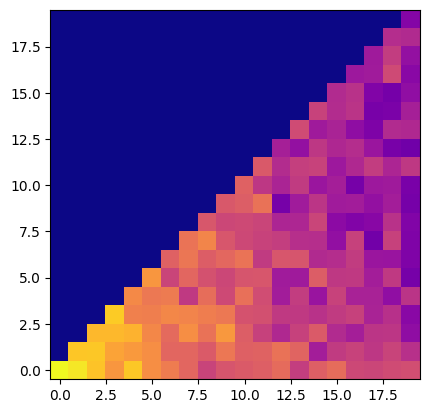

In [142]:
plt.imshow(results['overall']['rmse'], origin='lower', cmap='plasma')